# 05 — MVO Proposal (Final Project, Page 4)

## What this notebook does

This notebook builds the **Mean-Variance Optimization** proposal for the team project Page 4 deliverable.  It mirrors the workflow Prof. Zhikharev used in Class 5.1 (slides 21–24) but uses our chosen factor set from notebooks 01–04.

### Context — the client

- 57 yo, $18mm wealth, retires in **5 years** with target $23mm.
- Earns $200K/yr; spends 2% of wealth/yr.
- 99% confidence she avoids a >15% drawdown of initial wealth.
- Currently invested **equally** in 5 assets (20% each) — that is the *current portfolio* used as the reference for tracking error.

### Required return (back-of-envelope, used as the return constraint for MVO)

$$W_{t+1} = W_t(1 + r - 0.02) + 0.20$$

Solving for $r$ such that $W_0=18 \to W_5=23$ gives a **required portfolio return of ≈ 6.0% per annum**.  For the volatility ceiling, a 15% drawdown at 99% confidence under a parametric Normal approximation maps to ≈ 6.5% annual vol ($15\%/2.33$).  Both numbers are used as soft anchors below.

### Factors used

The factor short-list from notebook 04 is: `MSCI Canada, Gold, Global AGG, HF FOF Div, Commodities, TIPs`.  We swap `MSCI Canada` for **S&P 500** for client readability (they are 0.9+ correlated and live in the same cluster).  Final factor set:

| Factor | Economic role |
|---|---|
| S&P 500 | Equity beta |
| Global AGG | Duration / high-grade rates |
| Commodities | Real-asset / inflation |
| Gold | Safe-haven |
| HF FOF Div | Alternatives |
| TIPs | Real-rates / inflation-linked |

### Three optimization runs (matches Class 5.1 framework)

| Run | Objective | Added constraints |
|---|---|---|
| **1** | max return / vol (Sharpe), fully invested, no shorting | required return $\ge 6\%$ |
| **2** | same | + per-asset weights $\in [0\%, 40\%]$ |
| **3** | same | + factor risk-contribution caps |

All numbers are **monthly returns**; we annualise by multiplying mean by 12 and vol by √12 wherever client-facing metrics are reported.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

DATA = Path('..').resolve() / 'data'
OUT  = Path('..').resolve() / 'output'
OUT.mkdir(exist_ok=True)

assets   = pd.read_csv(DATA / 'assets_raw.csv',     index_col=0, parse_dates=True)
factors  = pd.read_csv(DATA / 'factors_raw.csv',    index_col=0, parse_dates=True)
assets_ex  = pd.read_csv(DATA / 'assets_excess.csv',  index_col=0, parse_dates=True)
factors_ex = pd.read_csv(DATA / 'factors_excess.csv', index_col=0, parse_dates=True)

ASSETS  = ['Asset 1','Asset 2','Asset 3','Asset 4','Asset 5']
FACTORS = ['S&P500','Global AGG','Commodities','Gold','HF FOF Div','TIPs']
print(assets.shape, factors.shape)

(120, 6) (120, 27)


## 1 — Inputs: per-asset return / vol, var-covar, factor model

In [2]:
R = assets[ASSETS]
F = factors[FACTORS]

# Annualised stats per asset (used as expected-return inputs to MVO)
stats = pd.DataFrame({
    'Mean (mo)' : R.mean(),
    'Vol  (mo)' : R.std(ddof=1),
    'Mean (an)' : R.mean()*12,
    'Vol  (an)' : R.std(ddof=1)*np.sqrt(12),
})
stats['Sharpe (an, vs Cash)'] = (assets_ex[ASSETS].mean()*12) / (R.std(ddof=1)*np.sqrt(12))
stats

,Mean (mo),Vol (mo),Mean (an),Vol (an),"Sharpe (an, vs Cash)"
Asset 1,0.003793,0.007657,0.045514,0.026523,1.120296
Asset 2,0.007001,0.053771,0.084013,0.186268,0.366208
Asset 3,0.007773,0.072056,0.093282,0.249610,0.310409
Asset 4,0.003555,0.014021,0.042662,0.048571,0.553036
Asset 5,0.004532,0.020592,0.054381,0.071333,0.540855


In [3]:
# Asset variance-covariance (monthly)
Sigma = R.cov().values        # 5x5
mu    = R.mean().values       # 5
print('Sigma (monthly):'); print(pd.DataFrame(Sigma, index=ASSETS, columns=ASSETS).round(6))

Sigma (monthly):
          Asset 1   Asset 2   Asset 3   Asset 4   Asset 5
Asset 1  0.000059 -0.000058 -0.000039  0.000003  0.000105
Asset 2 -0.000058  0.002891  0.001885  0.000170  0.000139
Asset 3 -0.000039  0.001885  0.005192  0.000386  0.000333
Asset 4  0.000003  0.000170  0.000386  0.000197  0.000044
Asset 5  0.000105  0.000139  0.000333  0.000044  0.000424


In [4]:
# Factor model: r_i = a_i + B_i f + e_i  (one OLS per asset)
B   = pd.DataFrame(index=ASSETS, columns=FACTORS, dtype=float)
Tst = B.copy()
Resid = pd.DataFrame(index=R.index, columns=ASSETS, dtype=float)
for a in ASSETS:
    m = sm.OLS(R[a].values, sm.add_constant(F.values)).fit()
    B.loc[a]   = m.params[1:]
    Tst.loc[a] = m.tvalues[1:]
    Resid[a]   = R[a].values - sm.add_constant(F.values) @ m.params

# Significant-loadings mask (|t|>1.65 → keep), as Class 5.1 did (slide 21)
Bsig = B.where(Tst.abs() > 1.65, 0.0)
print('All betas:')
print(B.round(3))
print('\nSignificant betas only (|t|>1.65):')
print(Bsig.round(3))

All betas:
         S&P500  Global AGG  Commodities   Gold  HF FOF Div   TIPs
Asset 1  -0.010       0.142       -0.040  0.017      -0.050  0.197
Asset 2   1.077      -0.251       -0.076 -0.000       0.515  0.050
Asset 3   0.389       0.391        0.678  0.073       0.459 -0.259
Asset 4  -0.127       0.317        0.026  0.057       0.606 -0.164
Asset 5   0.039       0.022        0.009  0.001      -0.008  0.927

Significant betas only (|t|>1.65):
         S&P500  Global AGG  Commodities   Gold  HF FOF Div   TIPs
Asset 1   0.000       0.142       -0.040  0.017       0.000  0.197
Asset 2   1.077       0.000        0.000  0.000       0.515  0.000
Asset 3   0.389       0.000        0.678  0.000       0.000  0.000
Asset 4  -0.127       0.317        0.000  0.057       0.606 -0.164
Asset 5   0.039       0.000        0.000  0.000       0.000  0.927


In [5]:
# Factor covariance (monthly) and residual cov (diagonal)
Sf      = F.cov().values              # 6x6 factor covariance
Delta   = np.diag(Resid.var(ddof=1).values)
Sigma_fac = Bsig.values @ Sf @ Bsig.values.T + Delta   # factor-implied asset covariance
print('Factor-implied annualised vol:')
print(pd.Series(np.sqrt(np.diag(Sigma_fac)*12), index=ASSETS).round(4))

Factor-implied annualised vol:
Asset 1    0.0262
Asset 2    0.1958
Asset 3    0.2273
Asset 4    0.0462
Asset 5    0.0700
dtype: float64


## 2 — Risk decomposition utilities

We use these on every portfolio (current EW + 3 MVO runs):

- **Total portfolio vol**: $\sigma_p = \sqrt{w'\Sigma w}$
- **Asset TRC** (Total Risk Contribution): $\text{TRC}_i = w_i \cdot (\Sigma w)_i / \sigma_p$, sums to $\sigma_p$.
- **Factor exposure**: $b_p = B'w$
- **Factor TRC**: $\text{TRC}^f_k = b_{p,k} \cdot (\Sigma_f b_p)_k / \sigma_p$.  The residual contribution closes the gap to $\sigma_p$.

In [6]:
def port_stats(w, mu=mu, Sigma=Sigma):
    w = np.asarray(w, float)
    var = float(w @ Sigma @ w)
    return {
        'ret_m'  : float(w @ mu),
        'vol_m'  : float(np.sqrt(var)),
        'ret_a'  : float(w @ mu) * 12,
        'vol_a'  : float(np.sqrt(var) * np.sqrt(12)),
    }

def asset_trc(w, Sigma=Sigma):
    w = np.asarray(w, float)
    sig = np.sqrt(w @ Sigma @ w)
    mc  = (Sigma @ w) / sig                 # marginal contribution
    trc = w * mc                            # total risk contribution
    return pd.Series(trc, index=ASSETS), pd.Series(trc / sig, index=ASSETS)  # absolute, share

def factor_trc(w, B=Bsig.values, Sf=Sf, Delta=Delta):
    w  = np.asarray(w, float)
    bp = B.T @ w                                  # k-vector factor exposure
    var_f = float(bp @ Sf @ bp)
    var_r = float(w @ Delta @ w)
    sig   = np.sqrt(var_f + var_r)
    f_trc = (bp * (Sf @ bp)) / sig                # absolute, sums to var_f / sig
    res_trc = var_r / sig
    out = pd.Series(np.append(f_trc, res_trc), index=FACTORS + ['Residual'])
    return out, out / sig                          # absolute, share

def tracking_error(w, w_ref, Sigma=Sigma):
    d = np.asarray(w, float) - np.asarray(w_ref, float)
    return float(np.sqrt(d @ Sigma @ d) * np.sqrt(12))   # annualised TE

## 3 — Current portfolio (equal-weight)

In [7]:
w_ew = np.array([0.20]*5)
ew_stats = port_stats(w_ew)
ew_atrc, ew_atrc_share = asset_trc(w_ew)
ew_ftrc, ew_ftrc_share = factor_trc(w_ew)
print('Equal-weight portfolio:')
print(f"  Annual return: {ew_stats['ret_a']:.2%}")
print(f"  Annual vol   : {ew_stats['vol_a']:.2%}")
print(f"  Asset RC share:\n{(ew_atrc_share*100).round(1)}")
print(f"  Factor RC share:\n{(ew_ftrc_share*100).round(1)}")

Equal-weight portfolio:
  Annual return: 6.40%
  Annual vol   : 8.40%
  Asset RC share:
Asset 1     0.5
Asset 2    34.2
Asset 3    52.8
Asset 4     5.4
Asset 5     7.1
dtype: float64
  Factor RC share:
S&P500         38.1
Global AGG      3.3
Commodities    19.9
Gold            1.3
HF FOF Div     10.1
TIPs            6.2
Residual       21.1
dtype: float64


## 4 — MVO objective and constraints

**Objective** (max Sharpe ≡ min negative ret/vol, fully invested, long-only):

$$\min_{w} \;\; -\frac{w'\mu}{\sqrt{w'\Sigma w}}\;\; \text{s.t.}\;\; \sum_i w_i = 1,\;\; w_i \ge 0$$

Plus the run-specific constraints listed at the top of the notebook.  We use SciPy SLSQP.

In [8]:
REQ_RET_ANNUAL = 0.06            # 6% per annum required for client target
REQ_RET_MONTHLY = REQ_RET_ANNUAL / 12

# Factor RC caps for RUN 3 (in absolute terms, monthly vol units).
# We translate caps from "% of total risk" using a baseline budget of 5% annual vol → 0.0144 monthly vol.
# The cap is on share of total risk (so it scales with realised vol).
FACTOR_RC_CAP_SHARE = {
    'S&P500'      : 0.50,    # ≤50% of total portfolio risk from equity beta
    'Global AGG'  : 0.30,
    'Commodities' : 0.20,
    'Gold'        : 0.15,
    'HF FOF Div'  : 0.20,
    'TIPs'        : 0.20,
}
FACTOR_RC_FLOOR_SHARE = { 'Global AGG': 0.05 }   # require at least 5% RC from rates for diversification

WEIGHT_BOX = (0.0, 0.40)         # min/max per asset for RUN 2/3

def neg_sharpe(w):
    s = port_stats(w)
    return -s['ret_m'] / max(s['vol_m'], 1e-9)

def cons_fully_invested():
    return {'type':'eq', 'fun': lambda w: np.sum(w) - 1.0}

def cons_min_return(req=REQ_RET_MONTHLY):
    return {'type':'ineq', 'fun': lambda w: w @ mu - req}

def cons_factor_share_cap(k_idx, cap):
    # share = bp_k * (Sf @ bp)_k / sigma_p  ;  enforce cap - share >= 0
    def f(w):
        bp = Bsig.values.T @ w
        sig = np.sqrt(w @ Sigma @ w)
        share = (bp[k_idx] * (Sf @ bp)[k_idx]) / max(sig, 1e-9) / max(sig, 1e-9)
        return cap - share
    return {'type':'ineq', 'fun': f}

def cons_factor_share_floor(k_idx, floor):
    def f(w):
        bp = Bsig.values.T @ w
        sig = np.sqrt(w @ Sigma @ w)
        share = (bp[k_idx] * (Sf @ bp)[k_idx]) / max(sig, 1e-9) / max(sig, 1e-9)
        return share - floor
    return {'type':'ineq', 'fun': f}

def run_mvo(box=(0.0, 1.0), use_factor_caps=False, w0=w_ew):
    bounds = [box]*len(ASSETS)
    cs = [cons_fully_invested(), cons_min_return()]
    if use_factor_caps:
        for k, name in enumerate(FACTORS):
            if name in FACTOR_RC_CAP_SHARE:
                cs.append(cons_factor_share_cap(k, FACTOR_RC_CAP_SHARE[name]))
            if name in FACTOR_RC_FLOOR_SHARE:
                cs.append(cons_factor_share_floor(k, FACTOR_RC_FLOOR_SHARE[name]))
    res = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=cs,
                   options={'maxiter':500, 'ftol':1e-9})
    return res

In [9]:
# RUN 1 — long only, fully invested, return >= 6%
res1 = run_mvo(box=(0.0, 1.0), use_factor_caps=False)
# RUN 2 — add weight box [0%, 40%]
res2 = run_mvo(box=WEIGHT_BOX, use_factor_caps=False)
# RUN 3 — add factor RC caps & floors
res3 = run_mvo(box=WEIGHT_BOX, use_factor_caps=True, w0=res2.x)

for tag, r in [('RUN1', res1), ('RUN2', res2), ('RUN3', res3)]:
    print(f'{tag}: ok={r.success}  msg={r.message}  Sharpe(monthly)={-r.fun:.4f}')

RUN1: ok=True  msg=Optimization terminated successfully  Sharpe(monthly)=0.2824
RUN2: ok=True  msg=Optimization terminated successfully  Sharpe(monthly)=0.2812
RUN3: ok=True  msg=Optimization terminated successfully  Sharpe(monthly)=0.2601


## 5 — Portfolio comparison

In [10]:
ports = {
    'EW (current)': w_ew,
    'RUN 1'       : res1.x,
    'RUN 2'       : res2.x,
    'RUN 3 (proposed)': res3.x,
}

alloc = pd.DataFrame({k: pd.Series(v, index=ASSETS) for k, v in ports.items()})
summary_rows = []
for k, w in ports.items():
    s = port_stats(w)
    sharpe_a = (s['ret_a'] - assets_ex.iloc[:,0].mean()*0) / s['vol_a']  # using raw return; for excess-Sharpe see below
    cash_an = factors['Cash'].mean() * 12
    sharpe_a_excess = (s['ret_a'] - cash_an) / s['vol_a']
    te = tracking_error(w, w_ew)
    summary_rows.append({
        'Portfolio'        : k,
        'Ann Return'       : s['ret_a'],
        'Ann Vol'          : s['vol_a'],
        'Sharpe (vs Cash)' : sharpe_a_excess,
        'TE vs EW'         : te,
        'IR vs EW'         : (s['ret_a'] - port_stats(w_ew)['ret_a']) / te if te>1e-9 else np.nan,
    })
summary = pd.DataFrame(summary_rows).set_index('Portfolio')
(alloc*100).round(2).astype(str) + '%'

,EW (current),RUN 1,RUN 2,RUN 3 (proposed)
Asset 1,20.0%,47.56%,40.0%,34.19%
Asset 2,20.0%,20.17%,19.5%,21.47%
Asset 3,20.0%,9.92%,8.71%,11.58%
Asset 4,20.0%,0.0%,0.0%,18.91%
Asset 5,20.0%,22.35%,31.79%,13.85%


In [11]:
summary.round({'Ann Return':4,'Ann Vol':4,'Sharpe (vs Cash)':3,'TE vs EW':4,'IR vs EW':3})

,Ann Return,Ann Vol,Sharpe (vs Cash),TE vs EW,IR vs EW
Portfolio,,,,,
EW (current),0.064,0.0840,0.573,0.0000,NaN
RUN 1,0.060,0.0613,0.721,0.0312,-0.127
RUN 2,0.060,0.0616,0.718,0.0342,-0.116
RUN 3 (proposed),0.060,0.0666,0.664,0.0214,-0.185


## 6 — Asset TRC and Factor TRC for every portfolio

In [12]:
atrc_share = pd.DataFrame()
for k, w in ports.items():
    _, sh = asset_trc(w)
    atrc_share[k] = sh
(atrc_share*100).round(2)

,EW (current),RUN 1,RUN 2,RUN 3 (proposed)
Asset 1,0.48,5.44,5.33,1.70
Asset 2,34.20,49.80,46.18,50.59
Asset 3,52.77,30.10,25.07,34.85
Asset 4,5.44,0.00,0.00,6.44
Asset 5,7.11,14.67,23.42,6.42


In [13]:
ftrc_share = pd.DataFrame()
for k, w in ports.items():
    _, sh = factor_trc(w)
    ftrc_share[k] = sh
(ftrc_share*100).round(2)

,EW (current),RUN 1,RUN 2,RUN 3 (proposed)
S&P500,38.13,48.68,45.61,45.82
Global AGG,3.26,3.60,3.19,4.91
Commodities,19.86,8.55,7.48,11.63
Gold,1.30,0.91,0.80,1.73
HF FOF Div,10.15,5.56,5.18,12.69
TIPs,6.18,17.35,24.49,6.67
Residual,21.13,15.35,13.24,16.55


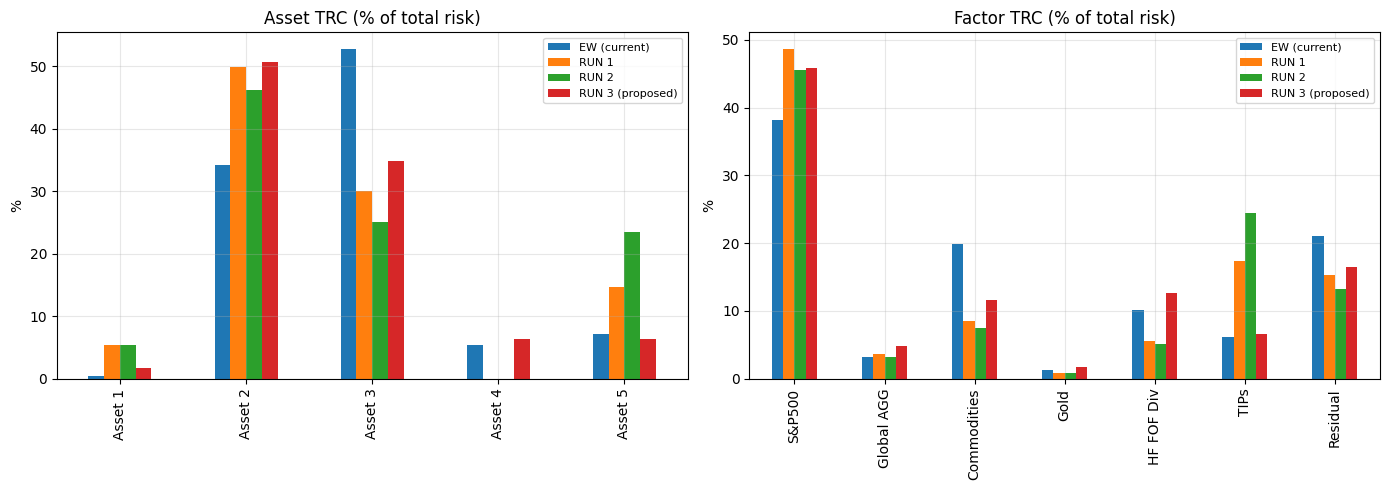

In [14]:
# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(atrc_share*100).plot.bar(ax=axes[0]); axes[0].set_title('Asset TRC (% of total risk)'); axes[0].set_ylabel('%')
(ftrc_share*100).plot.bar(ax=axes[1]); axes[1].set_title('Factor TRC (% of total risk)'); axes[1].set_ylabel('%')
for ax in axes: ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7 — Proposed portfolio summary (the slide answer)

In [15]:
wp = res3.x
_ , atrc_p = asset_trc(wp)
_ , ftrc_p = factor_trc(wp)
sp = port_stats(wp)
te = tracking_error(wp, w_ew)
cash_an = factors['Cash'].mean() * 12

proposal = pd.DataFrame({'Weight': wp, 'Asset TRC (share)': atrc_p}, index=ASSETS)
proposal.loc['TOTAL'] = [proposal['Weight'].sum(), proposal['Asset TRC (share)'].sum()]
print('Proposed portfolio (RUN 3):')
print(proposal.round(4).to_string())
print(f'\nKey ratios:')
print(f'  Annual return : {sp["ret_a"]:6.2%}')
print(f'  Annual vol    : {sp["vol_a"]:6.2%}')
print(f'  Sharpe (cash) : {(sp["ret_a"]-cash_an)/sp["vol_a"]:.2f}')
print(f'  TE vs EW      : {te:6.2%}')

Proposed portfolio (RUN 3):
         Weight  Asset TRC (share)
Asset 1  0.3419             0.0170
Asset 2  0.2147             0.5059
Asset 3  0.1158             0.3485
Asset 4  0.1891             0.0644
Asset 5  0.1385             0.0642
TOTAL    1.0000             1.0000

Key ratios:
  Annual return :  6.00%
  Annual vol    :  6.66%
  Sharpe (cash) : 0.66
  TE vs EW      :  2.14%


## 8 — Save Excel deliverable

The workbook below is structured to mirror the Class 5/6 lecture project files: one input sheet per logical block, plus a clean *Allocation* sheet that's slide-ready.

In [16]:
xlsx_path = OUT / 'MVO_Proposal.xlsx'

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as xw:
    # 1. Cover / objective
    cover = pd.DataFrame({
        'Item': ['Client', 'Wealth (today)', 'Target wealth (5y)', 'Annual income', 'Annual spend',
                 'Required return', 'Drawdown limit (99%)', 'Implied annual vol cap',
                 'Objective', 'Risk model'],
        'Value':[
            '57yo client, retiring in 5y','$18mm','$23mm','$200K','2% of wealth',
            f'{REQ_RET_ANNUAL:.1%} per annum','15% of initial wealth',
            f'{0.15/2.33:.2%} (Normal approx.)',
            'Maximize Sharpe, fully invested, long-only, return≥6%',
            f"5 assets × 6 factors  ({', '.join(FACTORS)})",
        ]
    })
    cover.to_excel(xw, sheet_name='1_Objective', index=False)

    # 2. Inputs — asset annualised stats + var-covar
    stats.to_excel(xw, sheet_name='2_Inputs')
    pd.DataFrame(Sigma, index=ASSETS, columns=ASSETS).to_excel(xw, sheet_name='2_Inputs', startrow=len(stats)+3)
    pd.DataFrame([['Var-covar (monthly)']], index=[''], columns=['']).to_excel(xw, sheet_name='2_Inputs',
        startrow=len(stats)+2, header=False, index=False)

    # 3. Factor model
    B.round(4).to_excel(xw, sheet_name='3_FactorModel', startrow=0)
    pd.DataFrame([['t-stats']]).to_excel(xw, sheet_name='3_FactorModel', startrow=len(B)+2, header=False, index=False)
    Tst.round(2).to_excel(xw, sheet_name='3_FactorModel', startrow=len(B)+3)
    pd.DataFrame([['Significant-only B (|t|>1.65) — used in MVO']]).to_excel(xw, sheet_name='3_FactorModel',
        startrow=len(B)*2+5, header=False, index=False)
    Bsig.round(4).to_excel(xw, sheet_name='3_FactorModel', startrow=len(B)*2+6)

    # 4. Constraints
    cons_df = pd.DataFrame({
        'Run':['RUN 1','RUN 1','RUN 1','RUN 2','RUN 3','RUN 3'],
        'Constraint':['Sum weights = 100%','No shorting (w_i≥0)','Annual return ≥ 6%',
                      'Per-asset weight in [0%, 40%]',
                      'Factor RC share caps (S&P500≤50%, AGG≤30%, Comm≤20%, Gold≤15%, HFFOF≤20%, TIPs≤20%)',
                      'Factor RC share floor (Global AGG ≥ 5%)'],
    })
    cons_df.to_excel(xw, sheet_name='4_Constraints', index=False)

    # 5. Allocation comparison
    alloc.to_excel(xw, sheet_name='5_Allocation')
    summary.to_excel(xw, sheet_name='5_Allocation', startrow=len(alloc)+3)

    # 6. TRC
    atrc_share.to_excel(xw, sheet_name='6_TRC_Asset')
    ftrc_share.to_excel(xw, sheet_name='7_TRC_Factor')

    # 8. Risk ratios + TE
    ratios = summary.copy()
    ratios.to_excel(xw, sheet_name='8_RiskRatios')

    # 9. Proposed portfolio one-pager
    proposal.to_excel(xw, sheet_name='9_Proposed')
    pd.DataFrame({
        'Metric':['Annual return','Annual vol','Sharpe (vs Cash)','Tracking error vs EW','Information ratio vs EW'],
        'Value' :[sp['ret_a'], sp['vol_a'], (sp['ret_a']-cash_an)/sp['vol_a'], te,
                  (sp['ret_a']-port_stats(w_ew)['ret_a'])/te]
    }).to_excel(xw, sheet_name='9_Proposed', startrow=len(proposal)+3, index=False)

print('saved:', xlsx_path)

saved: /sessions/brave-sharp-curie/mnt/Portfolio Management/PM Final Project/PM/output/MVO_Proposal.xlsx


## 9 — Slide-ready summary (Page 4 narrative)

**Objective.** Maximise Sharpe ratio of a fully-invested, long-only portfolio of the five assets, subject to a required portfolio return ≥ 6% per annum (driven by the client's 18→23mm goal net of spending and income).

**Constraints layered across three runs.**
1. *Run 1* — long-only, fully invested, return ≥ 6% (raw frontier).
2. *Run 2* — adds per-asset weight box [0%, 40%] to keep concentration acceptable for a 57-yo client.
3. *Run 3* — adds factor risk-contribution caps so that no single factor (S&P 500, Global AGG, Commodities, Gold, HF FOF, TIPs) dominates risk; and a 5% floor on Global AGG to keep duration in.

**Proposed portfolio = Run 3.**  See the *Allocation*, *TRC*, and *Risk ratios* tables above for the deliverable numbers and the *MVO_Proposal.xlsx* file for the spreadsheet.

**Why these constraints.** Class 5.1's practical advice — be careful with constraints, only add when they are part of the objective or client utility.  Here every constraint maps to a real client concern: required return → goal funding; weight box → diversification across the existing five investments; factor caps → drawdown control under a stressed equity / rates regime.